In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load data
df = pd.read_csv('ecommerce_churn_.csv')
print(df.shape)
print(df.head())
print(df.info())

(5630, 20)
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN                         3   

     PreferedOrderCat  SatisfactionScore MaritalSta

In [10]:
# Step 1: Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Step 2: Fill missing numbers with median, text with mode
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
    
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Step 3: Remove duplicates
df.drop_duplicates(inplace=True)
print(f"Rows after cleaning: {len(df)}")

# Step 4: Encode text columns to numbers
label_enc = LabelEncoder()
for col in cat_cols:
    df[col] = label_enc.fit_transform(df[col])

# Step 5: Check overall churn rate
churn_rate = df['Churn'].mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")
print(df['Churn'].value_counts())

Missing values per column:
CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64
Rows after cleaning: 5630
Overall churn rate: 16.8%
Churn
0    4682
1     948
Name: count, dtype: int64


C:\Users\suhan\AppData\Local\Temp\ipykernel_6416\3832762867.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\suhan\AppData\Local\Temp\ipykernel_6416\3832762867.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [11]:
# RFM uses 3 columns:
# Recency  → DaySinceLastOrder (lower = better, shopped recently)
# Frequency → OrderCount (higher = better, shops often)
# Monetary  → CashbackAmount (higher = better, more valuable)

# Score each customer 1-3 (3 = best)
df['R_score'] = pd.qcut(df['DaySinceLastOrder'], q=3, labels=[3,2,1]).astype(int)
df['F_score'] = pd.qcut(df['OrderCount'].rank(method='first'), q=3, labels=[1,2,3]).astype(int)
df['M_score'] = pd.qcut(df['CashbackAmount'], q=3, labels=[1,2,3]).astype(int)

# Combine into total RFM score (3–9)
df['RFM_Score'] = df['R_score'] + df['F_score'] + df['M_score']

# Assign segment labels
def assign_segment(score):
    if score >= 8: return 'Champion'
    elif score >= 6: return 'Loyal Customer'
    elif score >= 4: return 'At Risk'
    else: return 'Lost Customer'

df['RFM_Segment'] = df['RFM_Score'].apply(assign_segment)

# Summary by segment
rfm_summary = df.groupby('RFM_Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Churn_Rate=('Churn', 'mean')
).reset_index()
rfm_summary['Avg_Churn_Rate'] = (rfm_summary['Avg_Churn_Rate'] * 100).round(1)
print(rfm_summary)

# Save RFM file for GitHub
rfm_summary.to_csv('rfm_segments.csv', index=False)
print("rfm_segments.csv saved!")

      RFM_Segment  Customer_Count  Avg_Churn_Rate
0         At Risk            1839            20.2
1        Champion             592            15.0
2   Lost Customer             129             8.5
3  Loyal Customer            3070            15.5
rfm_segments.csv saved!


In [12]:
# Prepare features (X) and target (y)
drop_cols = ['CustomerID', 'Churn', 'R_score', 'F_score', 'M_score', 'RFM_Score', 'RFM_Segment']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['Churn']

# Split: 80% train, 20% test (stratified keeps churn ratio equal)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (makes all numbers comparable in size)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc*100:.1f}%")
print(classification_report(y_test, lr_pred, target_names=['Retained', 'Churned']))

# Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)
dt_pred = dt.predict(X_test_sc)
dt_acc = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_acc*100:.1f}%")
print(classification_report(y_test, dt_pred, target_names=['Retained', 'Churned']))

Logistic Regression Accuracy: 87.1%
              precision    recall  f1-score   support

    Retained       0.89      0.96      0.93       936
     Churned       0.69      0.43      0.53       190

    accuracy                           0.87      1126
   macro avg       0.79      0.70      0.73      1126
weighted avg       0.86      0.87      0.86      1126

Decision Tree Accuracy: 89.3%
              precision    recall  f1-score   support

    Retained       0.91      0.97      0.94       936
     Churned       0.78      0.51      0.62       190

    accuracy                           0.89      1126
   macro avg       0.84      0.74      0.78      1126
weighted avg       0.88      0.89      0.88      1126



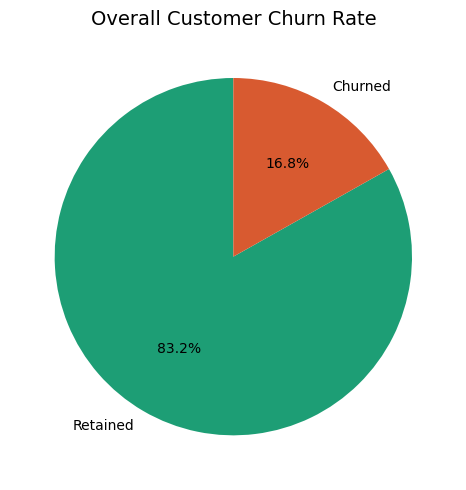

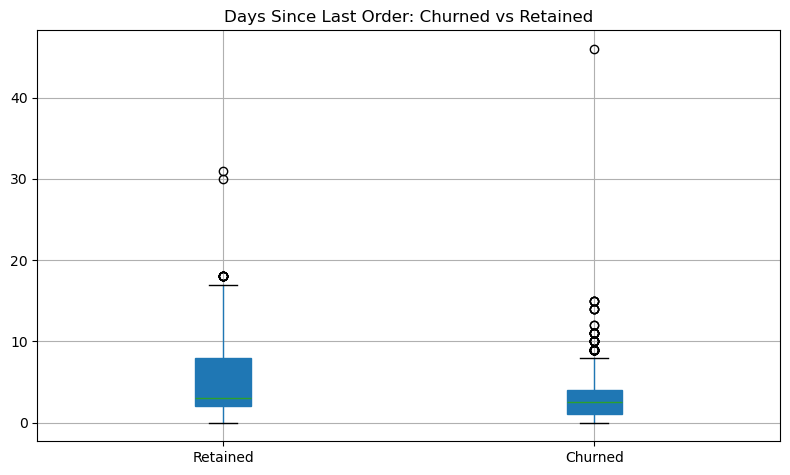

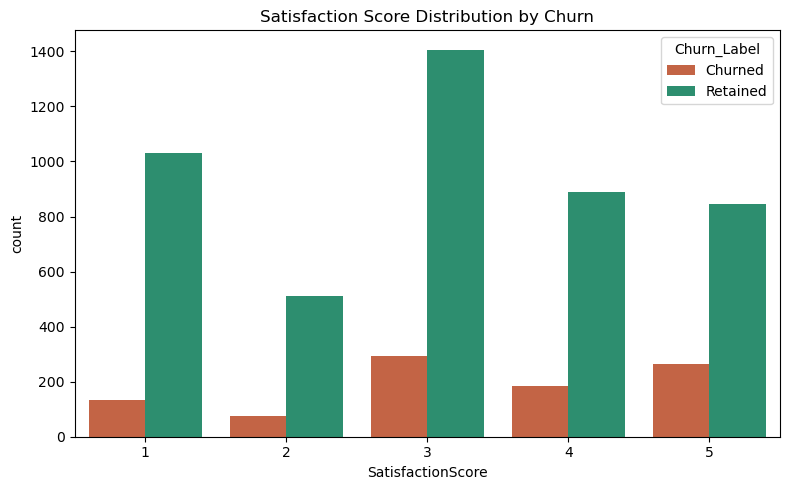

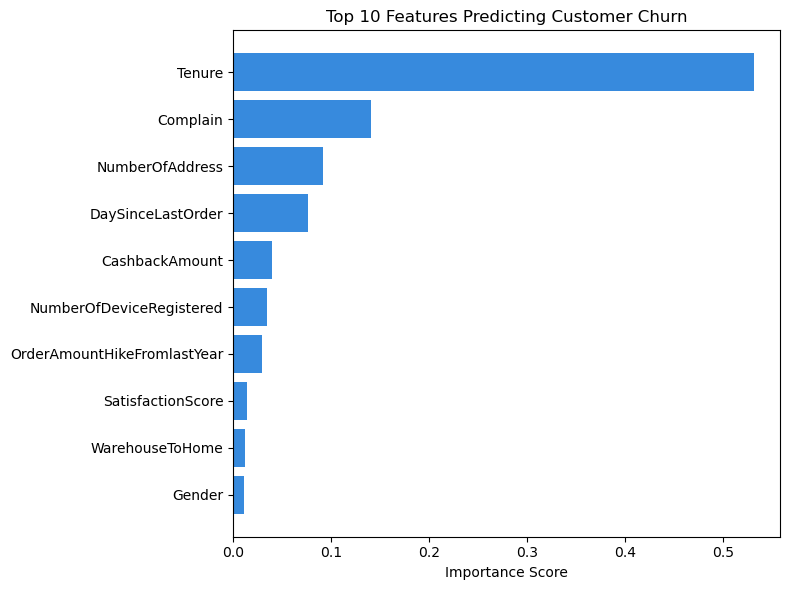

In [13]:
# Chart 1: Overall churn rate pie chart
fig, ax = plt.subplots(figsize=(6,5))
churn_counts = df['Churn'].value_counts()
ax.pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%',
       colors=['#1D9E75', '#D85A30'], startangle=90)
ax.set_title('Overall Customer Churn Rate', fontsize=14)
plt.tight_layout()
plt.savefig('chart1_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2: Days since last order — churned vs retained
fig, ax = plt.subplots(figsize=(8,5))
df.boxplot(column='DaySinceLastOrder', by='Churn', ax=ax,
           patch_artist=True)
ax.set_xticklabels(['Retained', 'Churned'])
ax.set_title('Days Since Last Order: Churned vs Retained')
ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.savefig('chart2_days_since_order.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3: Satisfaction score by churn
fig, ax = plt.subplots(figsize=(8,5))
df_plot = df.copy()
df_plot['Churn_Label'] = df_plot['Churn'].map({0:'Retained', 1:'Churned'})
sns.countplot(data=df_plot, x='SatisfactionScore', hue='Churn_Label',
              palette={'Retained':'#1D9E75', 'Churned':'#D85A30'}, ax=ax)
ax.set_title('Satisfaction Score Distribution by Churn')
plt.tight_layout()
plt.savefig('chart3_satisfaction_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 4: Feature importance from Decision Tree
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#378ADD')
ax.set_title('Top 10 Features Predicting Customer Churn')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Use whichever model performed better (usually Decision Tree here)
# We need probabilities for ALL customers
X_all_sc = scaler.transform(X)
df['Churn_Probability'] = dt.predict_proba(X_all_sc)[:,1]

# Assign risk tier
def risk_tier(prob):
    if prob >= 0.70: return 'High Risk'
    elif prob >= 0.40: return 'Medium Risk'
    else: return 'Low Risk'

df['Risk_Tier'] = df['Churn_Probability'].apply(risk_tier)

# Print distribution
print(df['Risk_Tier'].value_counts())
print(f"High Risk customers: {(df['Risk_Tier']=='High Risk').sum()}")

# Save the CRM deliverable file
output_cols = ['CustomerID', 'Churn', 'Churn_Probability', 'Risk_Tier',
               'RFM_Segment', 'DaySinceLastOrder', 'OrderCount', 'SatisfactionScore']
df[output_cols].to_csv('nykaa_churn_predictions.csv', index=False)
print("nykaa_churn_predictions.csv saved!")

Risk_Tier
Low Risk       4706
Medium Risk     499
High Risk       425
Name: count, dtype: int64
High Risk customers: 425
nykaa_churn_predictions.csv saved!
